<a href="https://colab.research.google.com/github/faizaan0619/MachineLearning/blob/main/Supervised/DecisionTree_RandomForest_teclo_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

In [ ]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
781,7521-AFHAB,Female,0,Yes,Yes,5,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,44.80,220.45,No
6737,9488-FYQAU,Female,0,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),109.25,6841.4,No
390,3597-MVHJT,Female,0,No,No,27,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),95.60,2595.25,No
2493,8622-ZLFKO,Female,0,Yes,No,6,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,90.75,512.25,No
6944,9039-ZVJDC,Male,0,No,No,3,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.10,53.05,No


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.shape

(7043, 21)

In [ ]:
df = df.drop(['customerID'], axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [ ]:
multi_categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                         'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                         'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_categorical_cols)

In [ ]:
X = df.drop(['Churn'], axis=1)
y = df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = DecisionTreeClassifier(criterion='gini',
                               max_depth=3,
                               random_state=42)

In [ ]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(y_test, model.predict(X_test))
print(f'Accuracy: {accuracy}')

Accuracy: 0.7955997161107168


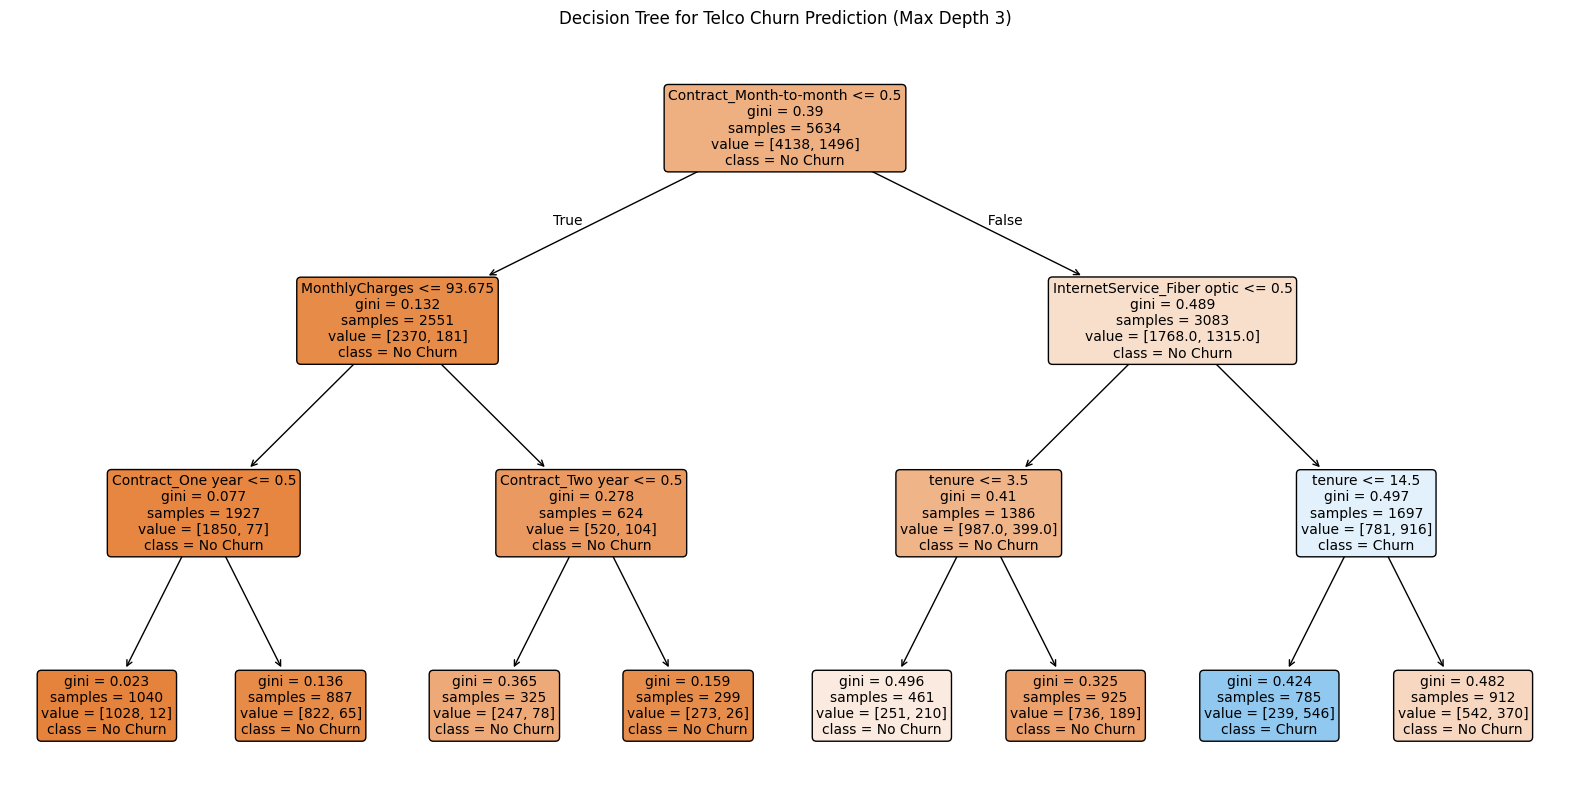

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(model,
          filled=True,
          feature_names=X.columns.tolist(),
          class_names=['No Churn', 'Churn'],
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Telco Churn Prediction (Max Depth 3)")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model = RandomForestClassifier(n_estimators=300,
                              max_depth=3,
                              random_state=42,
                              class_weight="balanced",
                               )

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=3, n_estimators=300,
                       random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.7317246273953159


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.69      0.79      1036
           1       0.50      0.85      0.63       373

    accuracy                           0.73      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.73      0.75      1409

[[714 322]
 [ 56 317]]


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_prob = model.predict_proba(X_test)[:, 1]

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.30 | Precision: 0.380 | Recall: 0.968 | F1: 0.545
Threshold: 0.35 | Precision: 0.414 | Recall: 0.949 | F1: 0.577
Threshold: 0.40 | Precision: 0.443 | Recall: 0.920 | F1: 0.598
Threshold: 0.45 | Precision: 0.468 | Recall: 0.869 | F1: 0.608
Threshold: 0.50 | Precision: 0.496 | Recall: 0.850 | F1: 0.626
Threshold: 0.55 | Precision: 0.522 | Recall: 0.812 | F1: 0.635
Threshold: 0.60 | Precision: 0.567 | Recall: 0.716 | F1: 0.633


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))

ROC-AUC: 0.8545550529464739
PR-AUC: 0.6716463334226952
